In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, f1_score
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.svm import SVR, SVC
from sklearn.dummy import DummyRegressor, DummyClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

print("✅ Setup complete")

✅ Setup complete


In [2]:
ds = pd.read_csv("earthquakes.csv")

print("=" * 60)
print("SHAPE:", ds.shape)
print("=" * 60)
print("\nCOLUMNS:")
for i, c in enumerate(ds.columns, 1):
    print(f"  {i:2d}. {c}  ({ds[c].dtype})")

print("\n" + "=" * 60)
print("FIRST 5 ROWS:")
print("=" * 60)
display(ds.head())

print("\n" + "=" * 60)
print("DATA TYPES + NON-NULL:")
print("=" * 60)
print(ds.info())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY:")
print("=" * 60)
display(ds.describe(include="all").T)

SHAPE: (8394, 18)

COLUMNS:
   1. id  (str)
   2. impact.gap  (float64)
   3. impact.magnitude  (float64)
   4. impact.significance  (int64)
   5. location.depth  (float64)
   6. location.distance  (float64)
   7. location.full  (str)
   8. location.latitude  (float64)
   9. location.longitude  (float64)
  10. location.name  (str)
  11. time.day  (int64)
  12. time.epoch  (int64)
  13. time.full  (str)
  14. time.hour  (int64)
  15. time.minute  (int64)
  16. time.month  (int64)
  17. time.second  (int64)
  18. time.year  (int64)

FIRST 5 ROWS:


,id,impact.gap,impact.magnitude,impact.significance,location.depth,location.distance,location.full,location.latitude,location.longitude,location.name,time.day,time.epoch,time.full,time.hour,time.minute,time.month,time.second,time.year
0,nc72666881,122.00,1.43,31,15.12,0.10340,"13km E of Livermore, California",37.672333,-121.619000,California,27,1469593183550,2016-07-27 00:19:43,0,19,7,43,2016
1,us20006i0y,30.00,4.90,371,97.07,1.43900,"58km WNW of Pakokku, Burma",21.514600,94.572100,Burma,27,1469593228220,2016-07-27 00:20:28,0,20,7,28,2016
2,nc72666891,249.00,0.06,0,4.39,0.02743,"12km SE of Mammoth Lakes, California",37.576500,-118.859167,California,27,1469593897150,2016-07-27 00:31:37,0,31,7,37,2016
3,nc72666896,122.00,0.40,2,1.09,0.02699,"6km SSW of Mammoth Lakes, California",37.595833,-118.994833,California,27,1469594144150,2016-07-27 00:35:44,0,35,7,44,2016
4,nn00553447,113.61,0.30,1,7.60,0.06300,"16km SSE of Mogul, Nevada",39.377500,-119.845000,Nevada,27,1469594519667,2016-07-27 00:41:59,0,41,7,59,2016



DATA TYPES + NON-NULL:
<class 'pandas.DataFrame'>
RangeIndex: 8394 entries, 0 to 8393
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8394 non-null   str    
 1   impact.gap           8394 non-null   float64
 2   impact.magnitude     8394 non-null   float64
 3   impact.significance  8394 non-null   int64  
 4   location.depth       8394 non-null   float64
 5   location.distance    8394 non-null   float64
 6   location.full        8394 non-null   str    
 7   location.latitude    8394 non-null   float64
 8   location.longitude   8394 non-null   float64
 9   location.name        8394 non-null   str    
 10  time.day             8394 non-null   int64  
 11  time.epoch           8394 non-null   int64  
 12  time.full            8394 non-null   str    
 13  time.hour            8394 non-null   int64  
 14  time.minute          8394 non-null   int64  
 15  time.month           8394

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,8394,8394,nc72666881,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impact.gap,8394.0,NaN,NaN,NaN,111.832581,81.410408,0.0,57.0,96.0,156.0,358.0
impact.magnitude,8394.0,NaN,NaN,NaN,1.512941,1.152668,0.01,0.74,1.2,1.88,7.7
impact.significance,8394.0,NaN,NaN,NaN,56.343817,96.677536,0.0,8.0,22.0,54.0,2674.0
location.depth,8394.0,NaN,NaN,NaN,23.051817,51.081531,-3.39,3.8,8.9,15.8,622.13
location.distance,8394.0,NaN,NaN,NaN,0.37582,1.547686,0.0,0.006667,0.0513,0.16765,40.547
location.full,8394,5051,"31km SSW of Hawthorne, Nevada",94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location.latitude,8394.0,NaN,NaN,NaN,39.713009,18.40484,-59.6119,34.051542,38.2721,51.80835,84.0291
location.longitude,8394.0,NaN,NaN,NaN,-111.863853,62.943337,-179.978,-146.52215,-119.73735,-116.7175,179.9594
location.name,8394,118,California,3609,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 2. MISSING VALUES
# ============================================================
missing = ds.isnull().sum()
missing_pct = (missing / len(ds) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent": missing_pct
}).sort_values("Percent", ascending=False)

print("Missing Value Report:")
print(missing_df[missing_df["Missing"] > 0] if (missing_df["Missing"] > 0).any()
      else "  ✅ No missing values")

# Graph: Missing values bar chart
if (missing_df["Missing"] > 0).any():
    plt.figure(figsize=(10, 4))
    plt.barh(missing_df.index, missing_df["Percent"], color="salmon")
    plt.xlabel("Missing %")
    plt.title("Missing Values Per Column")
    plt.tight_layout()
    plt.show()

Missing Value Report:
  ✅ No missing values


In [4]:
# ============================================================
# 3. DROP LEAKY + USELESS COLUMNS
# ============================================================
MAG_COL = "impact.magnitude"

# LEAKY (mathematically derived from magnitude → cause 99% fake R²)
LEAKY   = ["impact.significance", "impact.gap"]

# USELESS (unique IDs / redundant strings / redundant time)
USELESS = ["id", "time.full", "location.full", "time.epoch"]

drop_cols = [c for c in (LEAKY + USELESS) if c in ds.columns]
ds = ds.drop(columns=drop_cols)

print("✅ Dropped:", drop_cols)
print("New shape:", ds.shape)
print("Remaining columns:", ds.columns.tolist())

✅ Dropped: ['impact.significance', 'impact.gap', 'id', 'time.full', 'location.full', 'time.epoch']
New shape: (8394, 12)
Remaining columns: ['impact.magnitude', 'location.depth', 'location.distance', 'location.latitude', 'location.longitude', 'location.name', 'time.day', 'time.hour', 'time.minute', 'time.month', 'time.second', 'time.year']


In [5]:
# ============================================================
# 4. CLEAN TARGET
# ============================================================
ds = ds.dropna(subset=[MAG_COL]).reset_index(drop=True)
ds[MAG_COL] = pd.to_numeric(ds[MAG_COL], errors="coerce")
ds = ds.dropna(subset=[MAG_COL]).reset_index(drop=True)

# Physical range: magnitudes are 0–10
ds = ds[(ds[MAG_COL] >= 0) & (ds[MAG_COL] <= 10)].reset_index(drop=True)

print("✅ Cleaned shape:", ds.shape)
print(f"Magnitude range: {ds[MAG_COL].min():.2f} → {ds[MAG_COL].max():.2f}")
print(f"Mean: {ds[MAG_COL].mean():.2f} | Median: {ds[MAG_COL].median():.2f}")

✅ Cleaned shape: (8394, 12)
Magnitude range: 0.01 → 7.70
Mean: 1.51 | Median: 1.20


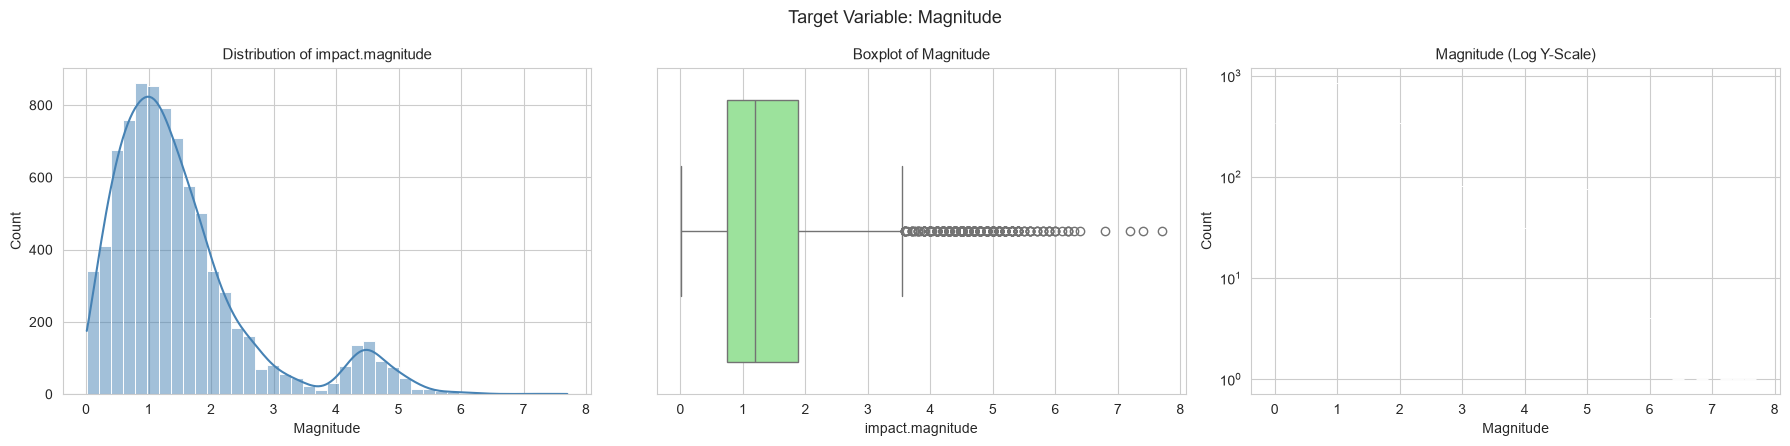

Skewness: 1.593
Kurtosis: 2.426
Std Dev : 1.153


In [6]:
# ============================================================
# 5. UNIVARIATE — TARGET DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Histogram + KDE
sns.histplot(ds[MAG_COL], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"Distribution of {MAG_COL}")
axes[0].set_xlabel("Magnitude")

# Boxplot
sns.boxplot(x=ds[MAG_COL], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of Magnitude")

# Log-scale histogram (to see rare large quakes)
sns.histplot(ds[MAG_COL], bins=40, ax=axes[2], color="coral", log_scale=(False, True))
axes[2].set_title("Magnitude (Log Y-Scale)")
axes[2].set_xlabel("Magnitude")

plt.suptitle("Target Variable: Magnitude", fontsize=13)
plt.tight_layout()
plt.show()

# Statistics
print(f"Skewness: {ds[MAG_COL].skew():.3f}")
print(f"Kurtosis: {ds[MAG_COL].kurtosis():.3f}")
print(f"Std Dev : {ds[MAG_COL].std():.3f}")

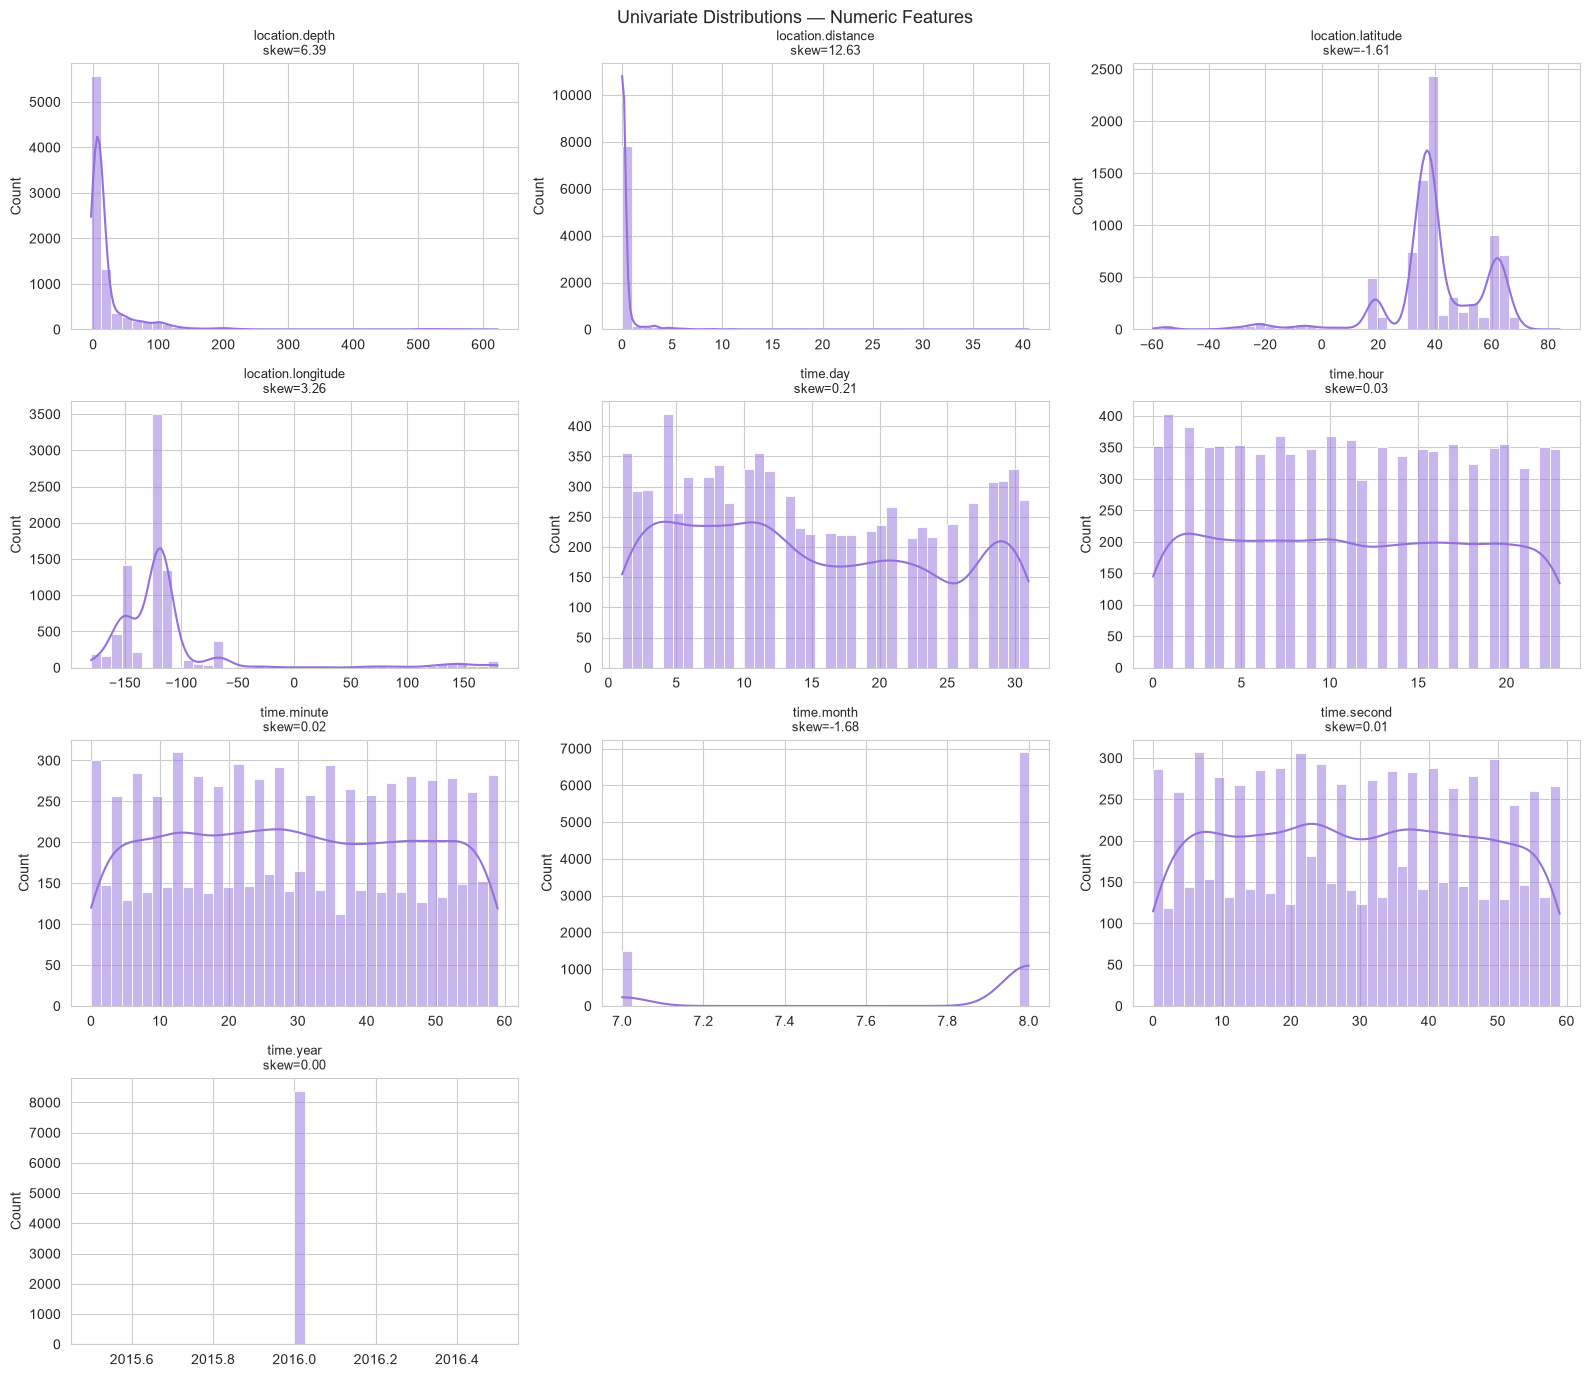

In [7]:
# ============================================================
# 6. UNIVARIATE — ALL NUMERIC FEATURES
# ============================================================
num_cols = ds.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != MAG_COL]

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(ds[col], bins=40, kde=True, ax=axes[i], color="mediumpurple")
    axes[i].set_title(f"{col}\nskew={ds[col].skew():.2f}", fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Univariate Distributions — Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

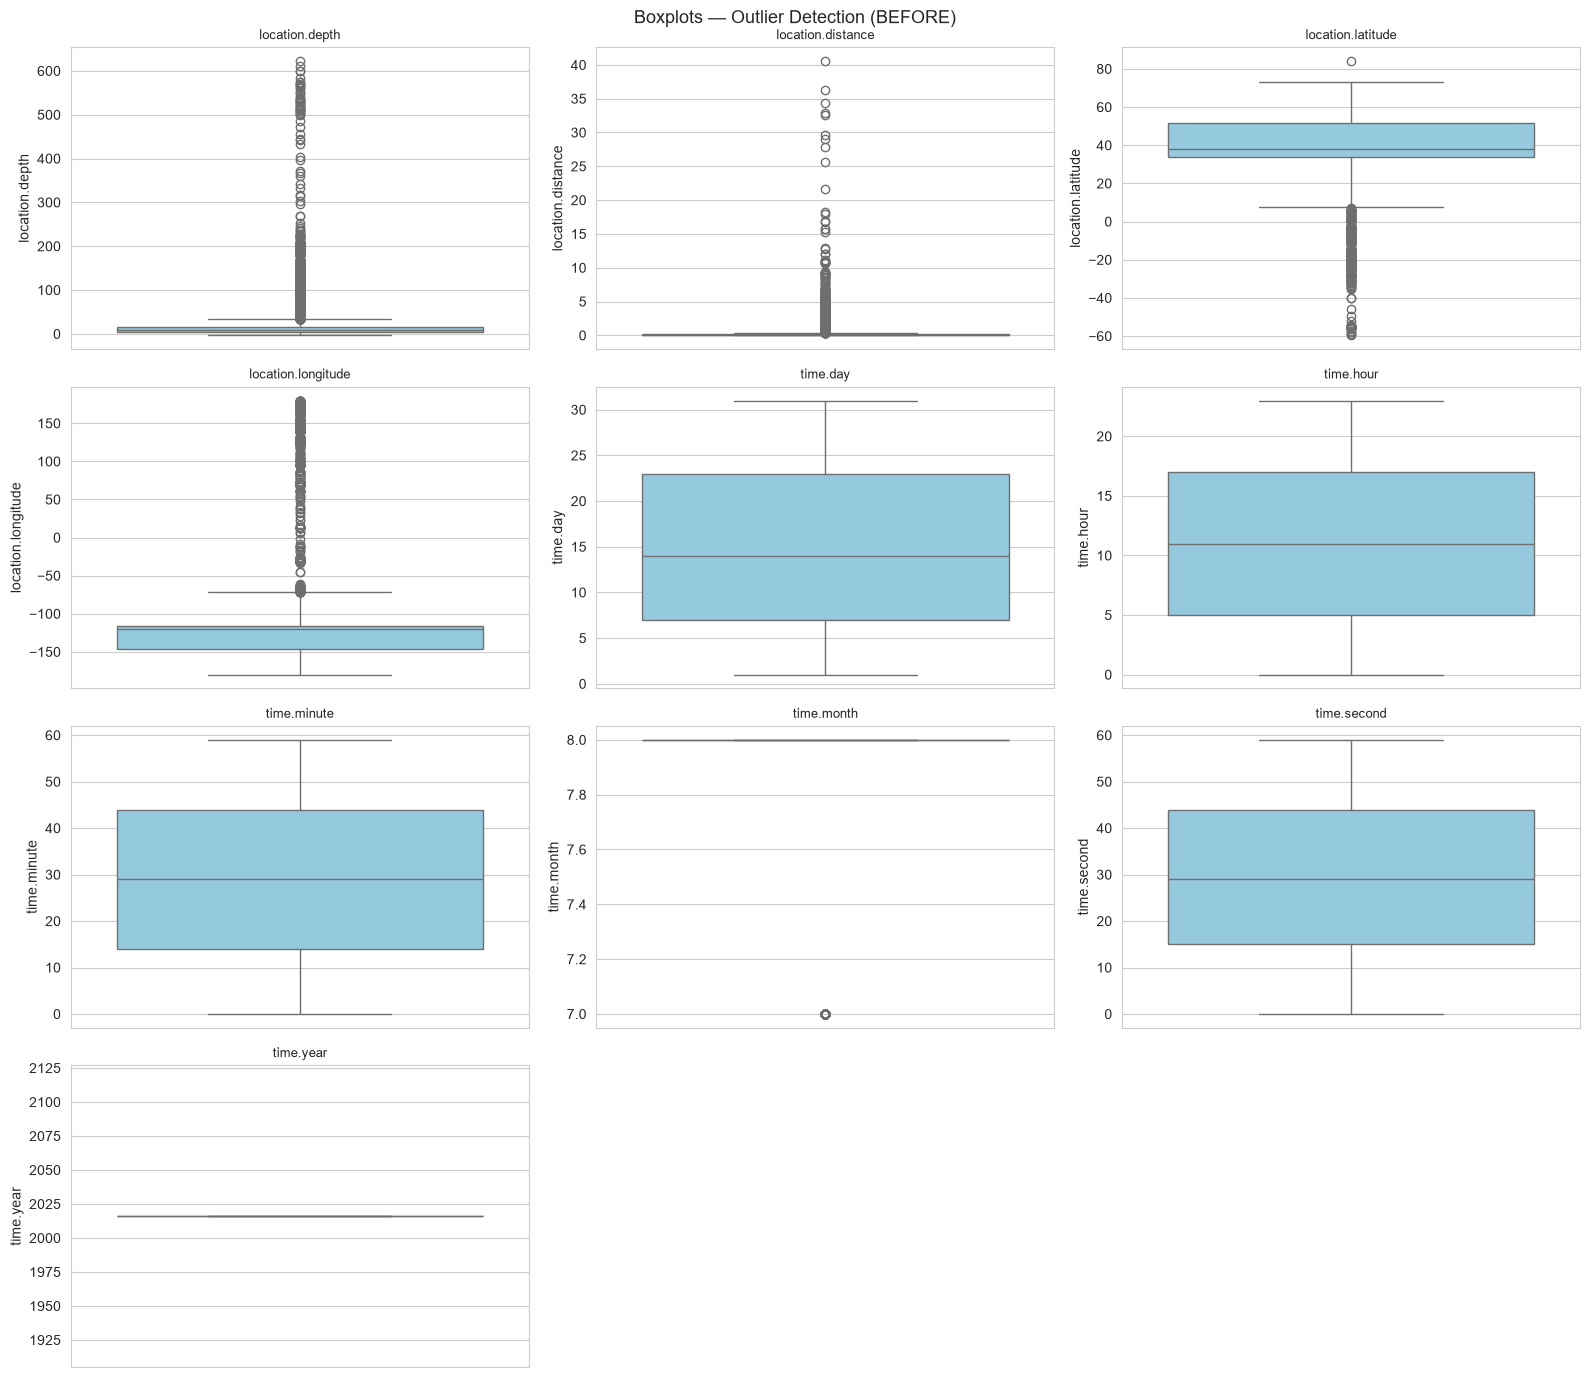


Outlier counts (IQR × 1.5 rule):
  location.depth           :  1383 (16.5%)
  location.distance        :  1096 (13.1%)
  location.latitude        :   373 (4.4%)
  location.longitude       :   885 (10.5%)
  time.day                 :     0 (0.0%)
  time.hour                :     0 (0.0%)
  time.minute              :     0 (0.0%)
  time.month               :  1496 (17.8%)
  time.second              :     0 (0.0%)
  time.year                :     0 (0.0%)


In [8]:
# ============================================================
# 7. OUTLIER DETECTION — BOXPLOTS (BEFORE)
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=ds[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Boxplots — Outlier Detection (BEFORE)", fontsize=13)
plt.tight_layout()
plt.show()

# Print IQR-based outlier counts per feature
print("\nOutlier counts (IQR × 1.5 rule):")
for col in num_cols:
    q1, q3 = ds[col].quantile(0.25), ds[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((ds[col] < q1 - 1.5*iqr) | (ds[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col:25s}: {n_out:5d} ({n_out/len(ds)*100:.1f}%)")

In [9]:
# ============================================================
# 8. OUTLIER REMOVAL (IQR × 3 — conservative)
# ============================================================
def remove_outliers_iqr(df, columns, k=3.0):
    df = df.copy()
    mask = pd.Series(True, index=df.index)
    for col in columns:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        mask &= df[col].between(q1 - k*iqr, q3 + k*iqr)
    return df[mask].reset_index(drop=True)

# Skip time components (not real "outliers" in that sense)
skip = ["time.year", "time.month", "time.day",
        "time.hour", "time.minute", "time.second"]
outlier_cols = [c for c in num_cols if c not in skip]

before = len(ds)
ds = remove_outliers_iqr(ds, outlier_cols, k=3.0)
after = len(ds)
print(f"✅ Outlier removal: {before} → {after} rows  "
      f"({before - after} removed, {(before-after)/before*100:.1f}%)")

✅ Outlier removal: 8394 → 6892 rows  (1502 removed, 17.9%)


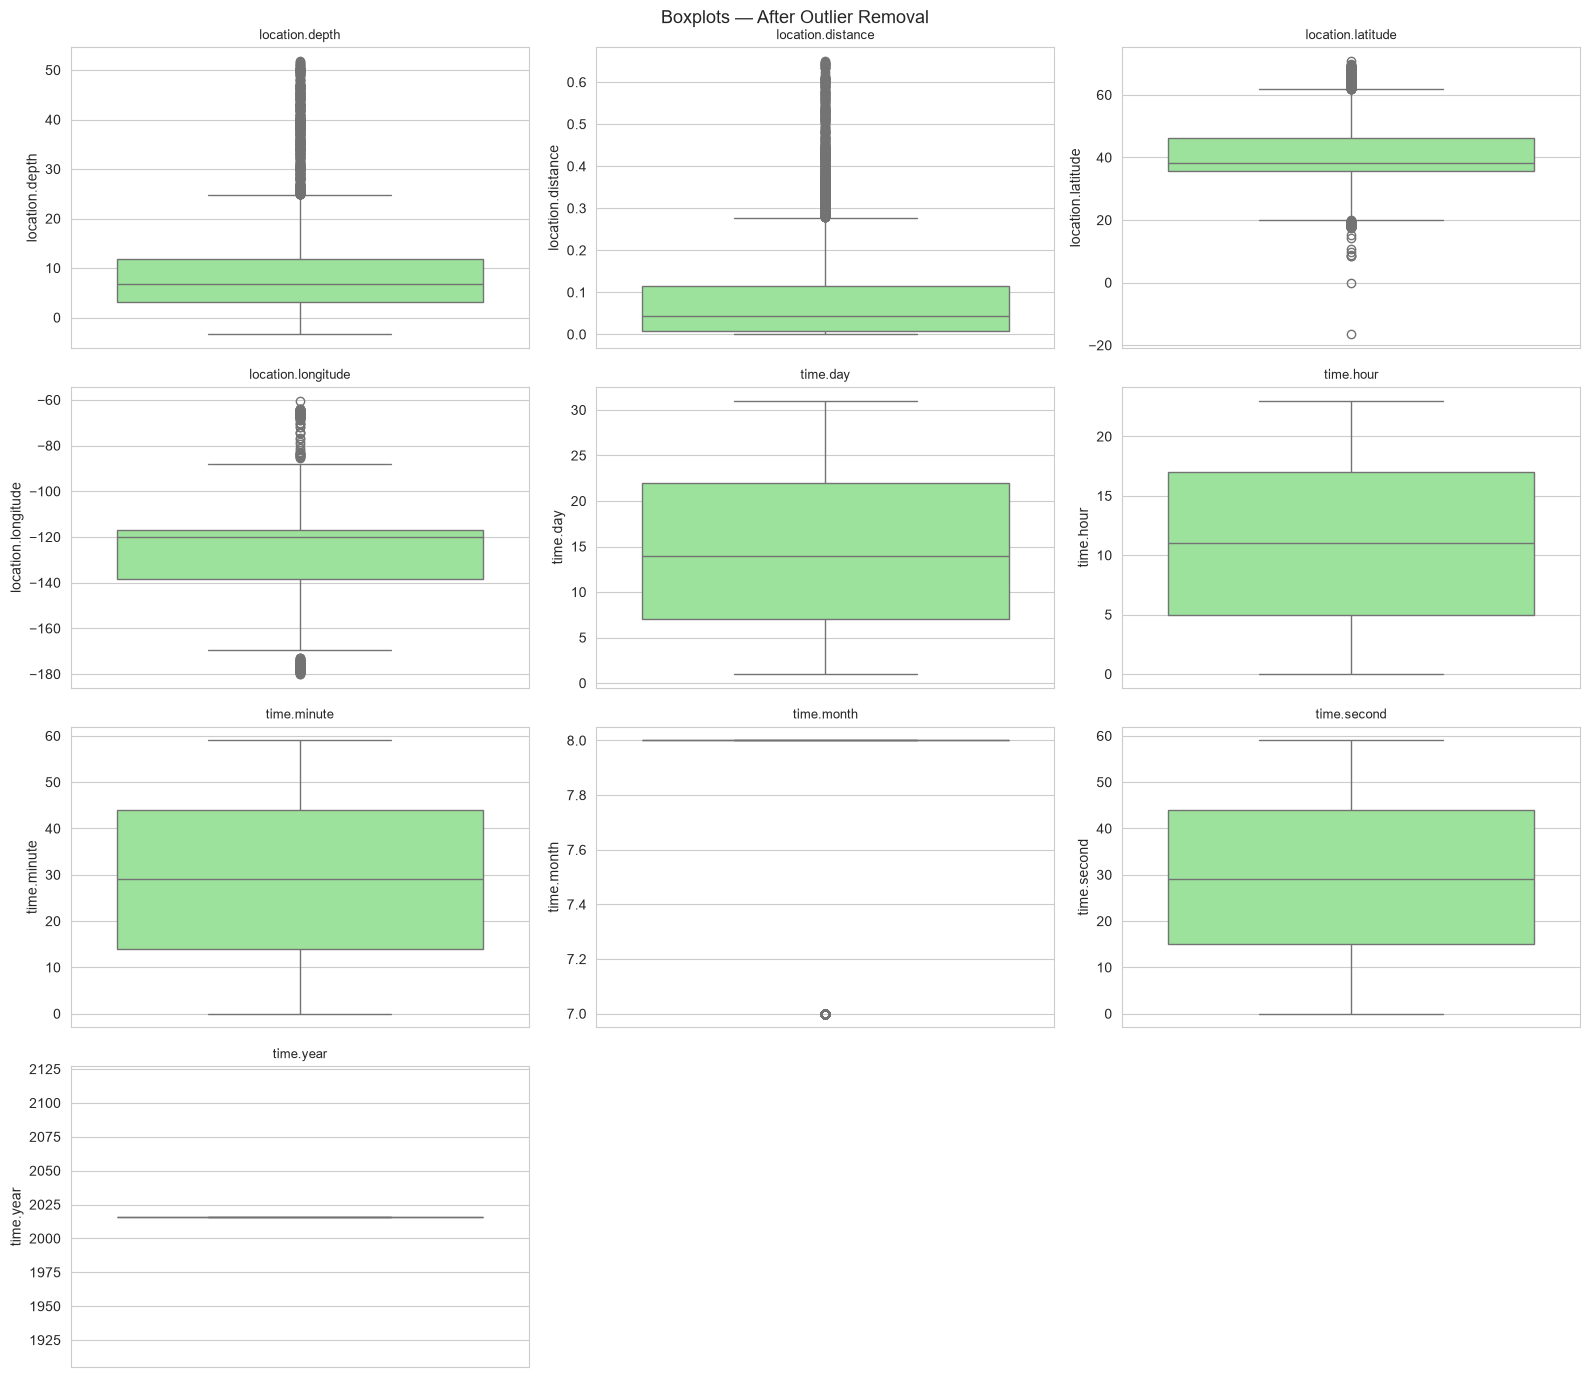

In [10]:
# ============================================================
# 9. BOXPLOTS AFTER REMOVAL
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=ds[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Boxplots — After Outlier Removal", fontsize=13)
plt.tight_layout()
plt.show()

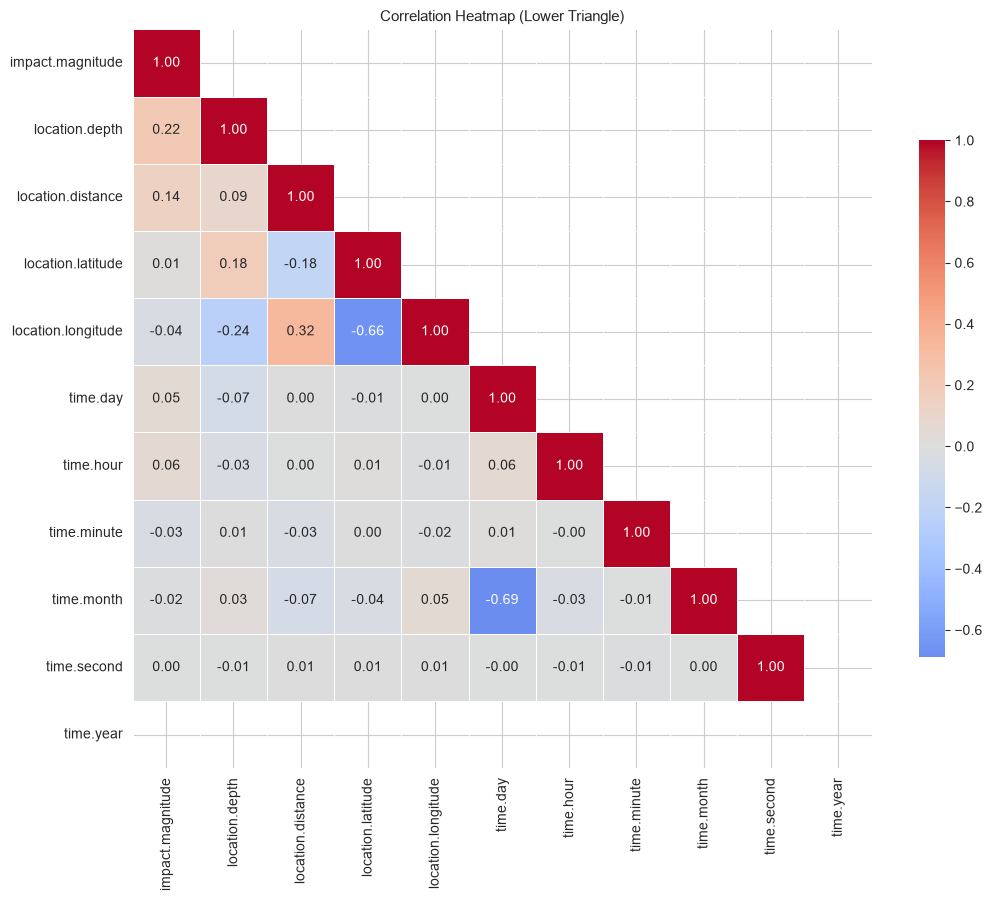


CORRELATION WITH TARGET (Magnitude):
location.depth        0.219017
location.distance     0.137040
time.hour             0.055998
time.day              0.052793
location.latitude     0.014040
time.second           0.002051
time.month           -0.016083
time.minute          -0.032606
location.longitude   -0.035154
time.year                  NaN
Name: impact.magnitude, dtype: float64


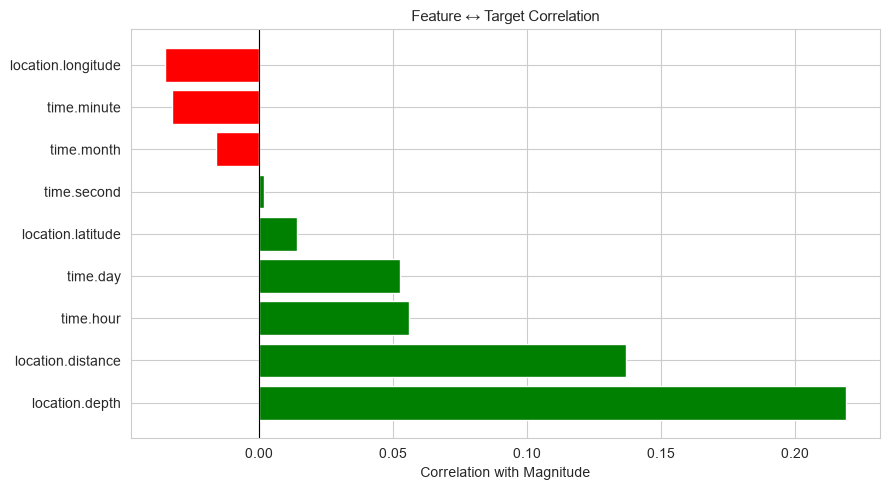

In [11]:
# ============================================================
# 10. CORRELATION HEATMAP
# ============================================================
corr = ds.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, linewidths=0.5)
plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

# Correlations with target, sorted
print("\n" + "=" * 60)
print("CORRELATION WITH TARGET (Magnitude):")
print("=" * 60)
target_corr = corr[MAG_COL].drop(MAG_COL).sort_values(ascending=False)
print(target_corr)

# Bar chart
plt.figure(figsize=(9, 5))
colors = ["green" if v > 0 else "red" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Magnitude")
plt.title("Feature ↔ Target Correlation")
plt.tight_layout()
plt.show()

C:\Users\GAURAVMISHRA\AppData\Local\Temp\ipykernel_19080\1931214665.py:14: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(ds[col].dropna(), ds[MAG_COL][ds[col].notna()], 1)


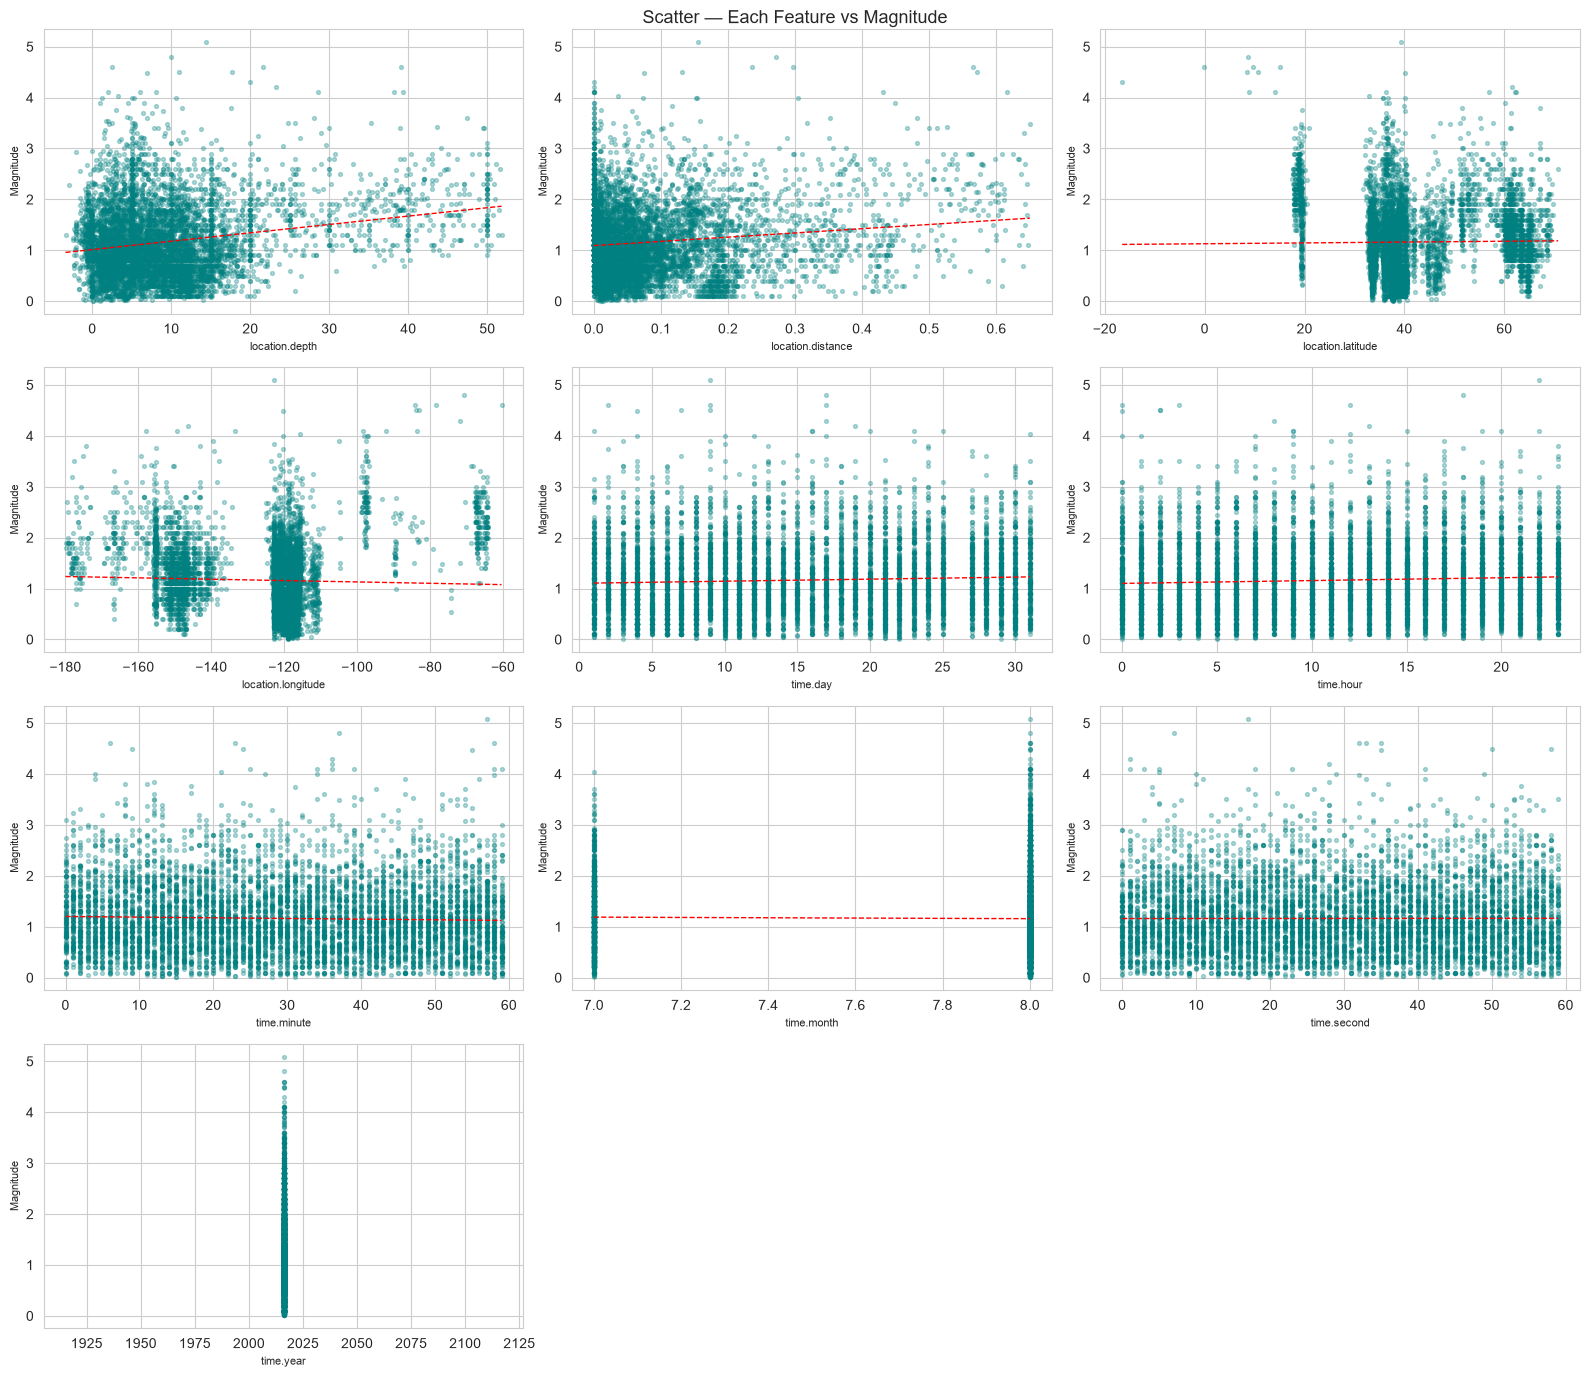

In [12]:
# ============================================================
# 11. BIVARIATE — FEATURES vs TARGET
# ============================================================
# Scatter plots: each numeric feature vs magnitude
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(ds[col], ds[MAG_COL], alpha=0.3, s=8, color="teal")
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Magnitude", fontsize=8)
    # Add trend line
    try:
        z = np.polyfit(ds[col].dropna(), ds[MAG_COL][ds[col].notna()], 1)
        p = np.poly1d(z)
        xr = np.linspace(ds[col].min(), ds[col].max(), 100)
        axes[i].plot(xr, p(xr), "r--", linewidth=1)
    except Exception:
        pass

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Scatter — Each Feature vs Magnitude", fontsize=13)
plt.tight_layout()
plt.show()

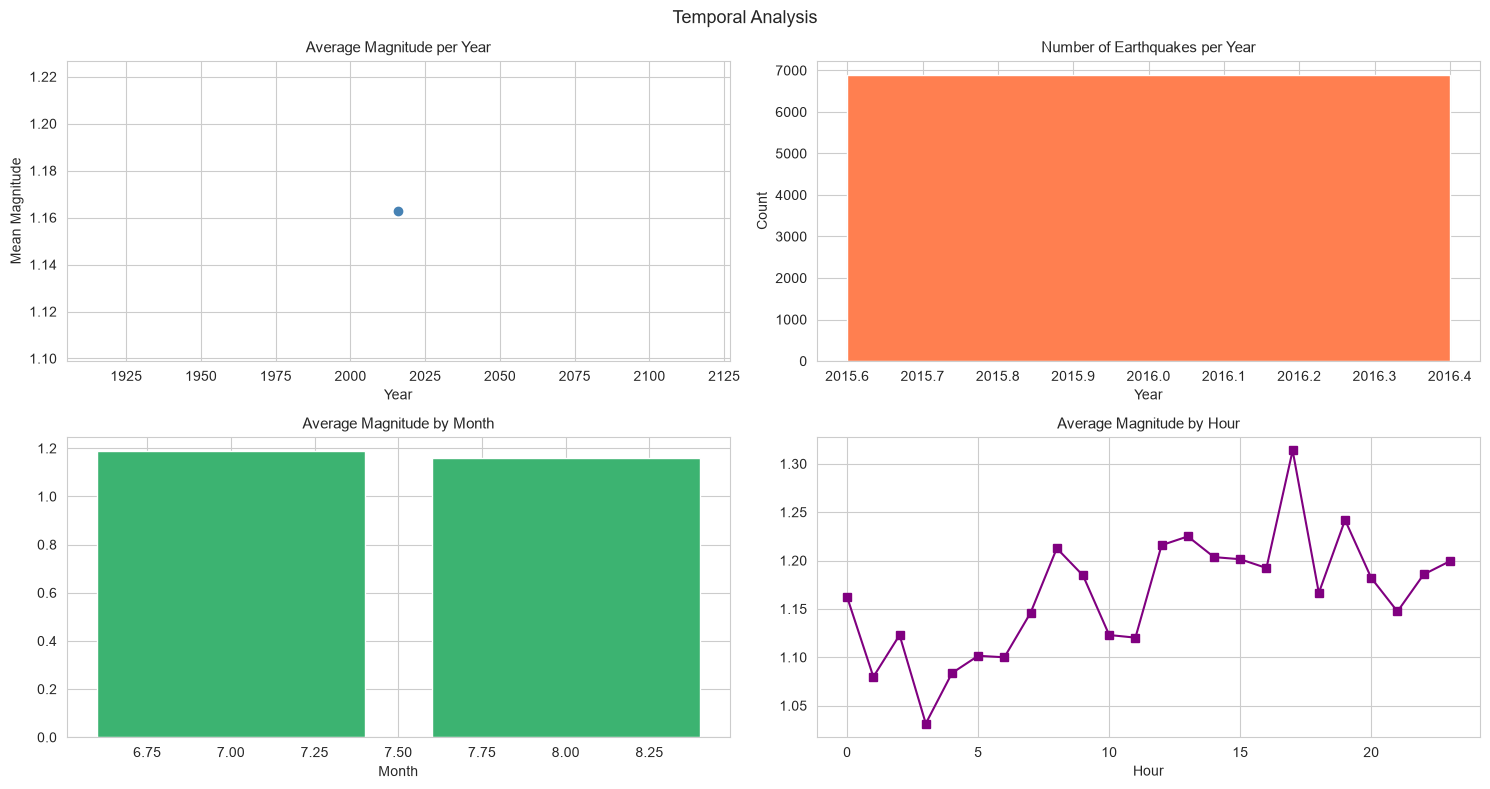

In [13]:
# ============================================================
# 12. TEMPORAL ANALYSIS
# ============================================================
if "time.year" in ds.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Yearly trend
    yearly = ds.groupby("time.year")[MAG_COL].agg(["mean", "count"]).reset_index()
    axes[0, 0].plot(yearly["time.year"], yearly["mean"], marker="o", color="steelblue")
    axes[0, 0].set_title("Average Magnitude per Year")
    axes[0, 0].set_xlabel("Year")
    axes[0, 0].set_ylabel("Mean Magnitude")

    # Yearly count
    axes[0, 1].bar(yearly["time.year"], yearly["count"], color="coral")
    axes[0, 1].set_title("Number of Earthquakes per Year")
    axes[0, 1].set_xlabel("Year")
    axes[0, 1].set_ylabel("Count")

    # Monthly pattern
    if "time.month" in ds.columns:
        monthly = ds.groupby("time.month")[MAG_COL].mean()
        axes[1, 0].bar(monthly.index, monthly.values, color="mediumseagreen")
        axes[1, 0].set_title("Average Magnitude by Month")
        axes[1, 0].set_xlabel("Month")

    # Hourly pattern
    if "time.hour" in ds.columns:
        hourly = ds.groupby("time.hour")[MAG_COL].mean()
        axes[1, 1].plot(hourly.index, hourly.values, marker="s", color="purple")
        axes[1, 1].set_title("Average Magnitude by Hour")
        axes[1, 1].set_xlabel("Hour")

    plt.suptitle("Temporal Analysis", fontsize=13)
    plt.tight_layout()
    plt.show()

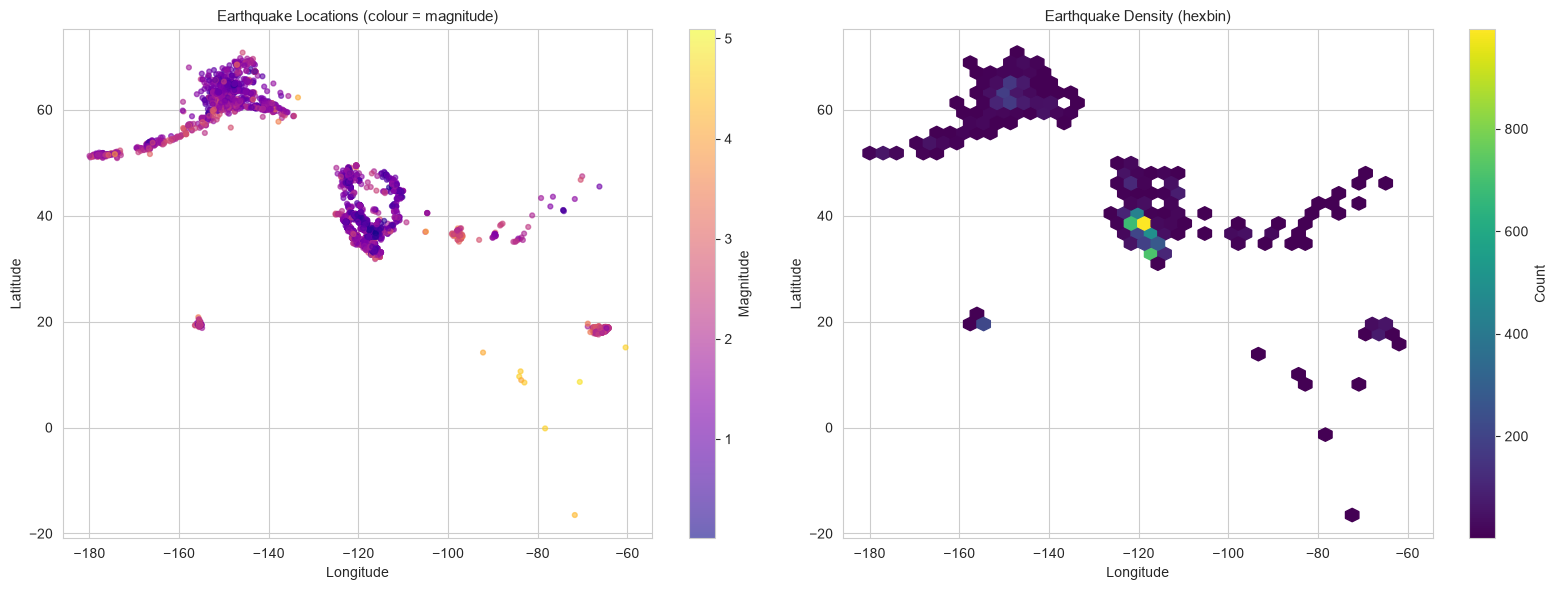

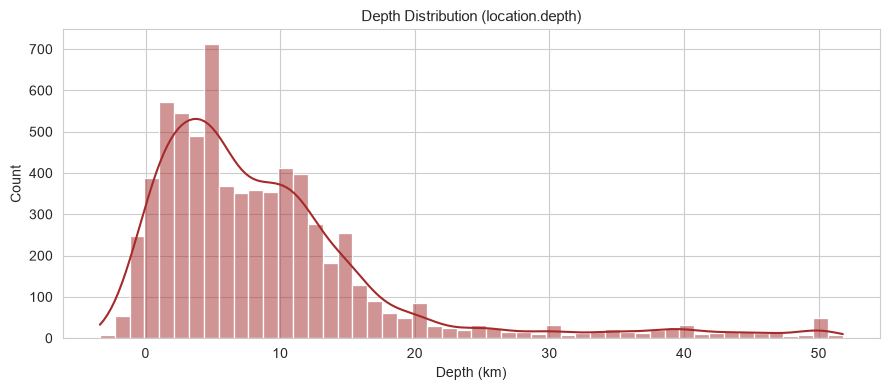

In [14]:
# ============================================================
# 13. SPATIAL ANALYSIS
# ============================================================
lat_col = next((c for c in ds.columns if "latitude" in c.lower()), None)
lon_col = next((c for c in ds.columns if "longitude" in c.lower()), None)
dep_col = next((c for c in ds.columns if "depth" in c.lower()), None)

if lat_col and lon_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Scatter map coloured by magnitude
    sc = axes[0].scatter(ds[lon_col], ds[lat_col],
                         c=ds[MAG_COL], cmap="plasma",
                         s=12, alpha=0.6)
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_title("Earthquake Locations (colour = magnitude)")
    plt.colorbar(sc, ax=axes[0], label="Magnitude")

    # Hexbin density
    hb = axes[1].hexbin(ds[lon_col], ds[lat_col], gridsize=40,
                        cmap="viridis", mincnt=1)
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].set_title("Earthquake Density (hexbin)")
    plt.colorbar(hb, ax=axes[1], label="Count")

    plt.tight_layout()
    plt.show()

if dep_col:
    plt.figure(figsize=(9, 4))
    sns.histplot(ds[dep_col], bins=50, kde=True, color="brown")
    plt.title(f"Depth Distribution ({dep_col})")
    plt.xlabel("Depth (km)")
    plt.tight_layout()
    plt.show()

Categorical columns: ['location.name']


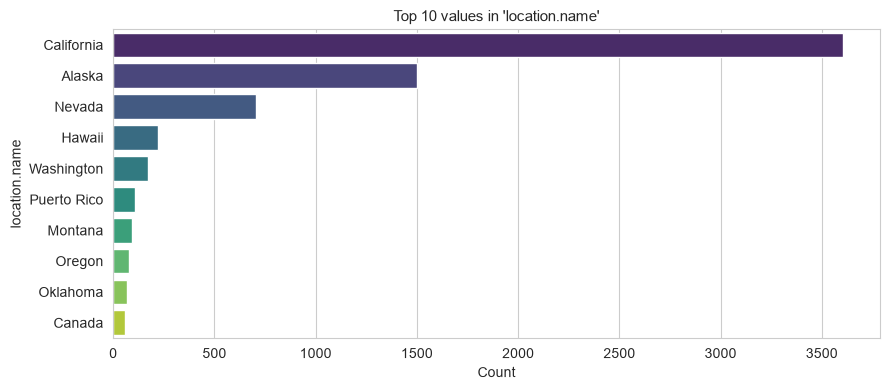

In [15]:
# ============================================================
# 14. CATEGORICAL ANALYSIS
# ============================================================
cat_cols = ds.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols)

# Top 10 categories per cat feature
for col in cat_cols:
    top = ds[col].value_counts().head(10)
    plt.figure(figsize=(9, 4))
    sns.barplot(x=top.values, y=top.index, palette="viridis")
    plt.title(f"Top 10 values in '{col}'")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

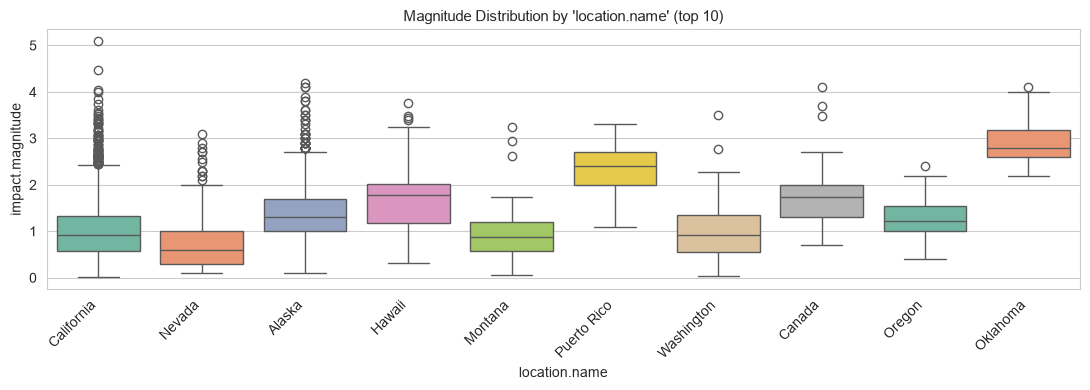

In [16]:
# ============================================================
# 15. MAGNITUDE DISTRIBUTION ACROSS CATEGORIES
# ============================================================
for col in cat_cols:
    top10 = ds[col].value_counts().nlargest(10).index
    sub = ds[ds[col].isin(top10)]

    plt.figure(figsize=(11, 4))
    sns.boxplot(data=sub, x=col, y=MAG_COL, palette="Set2")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Magnitude Distribution by '{col}' (top 10)")
    plt.tight_layout()
    plt.show()

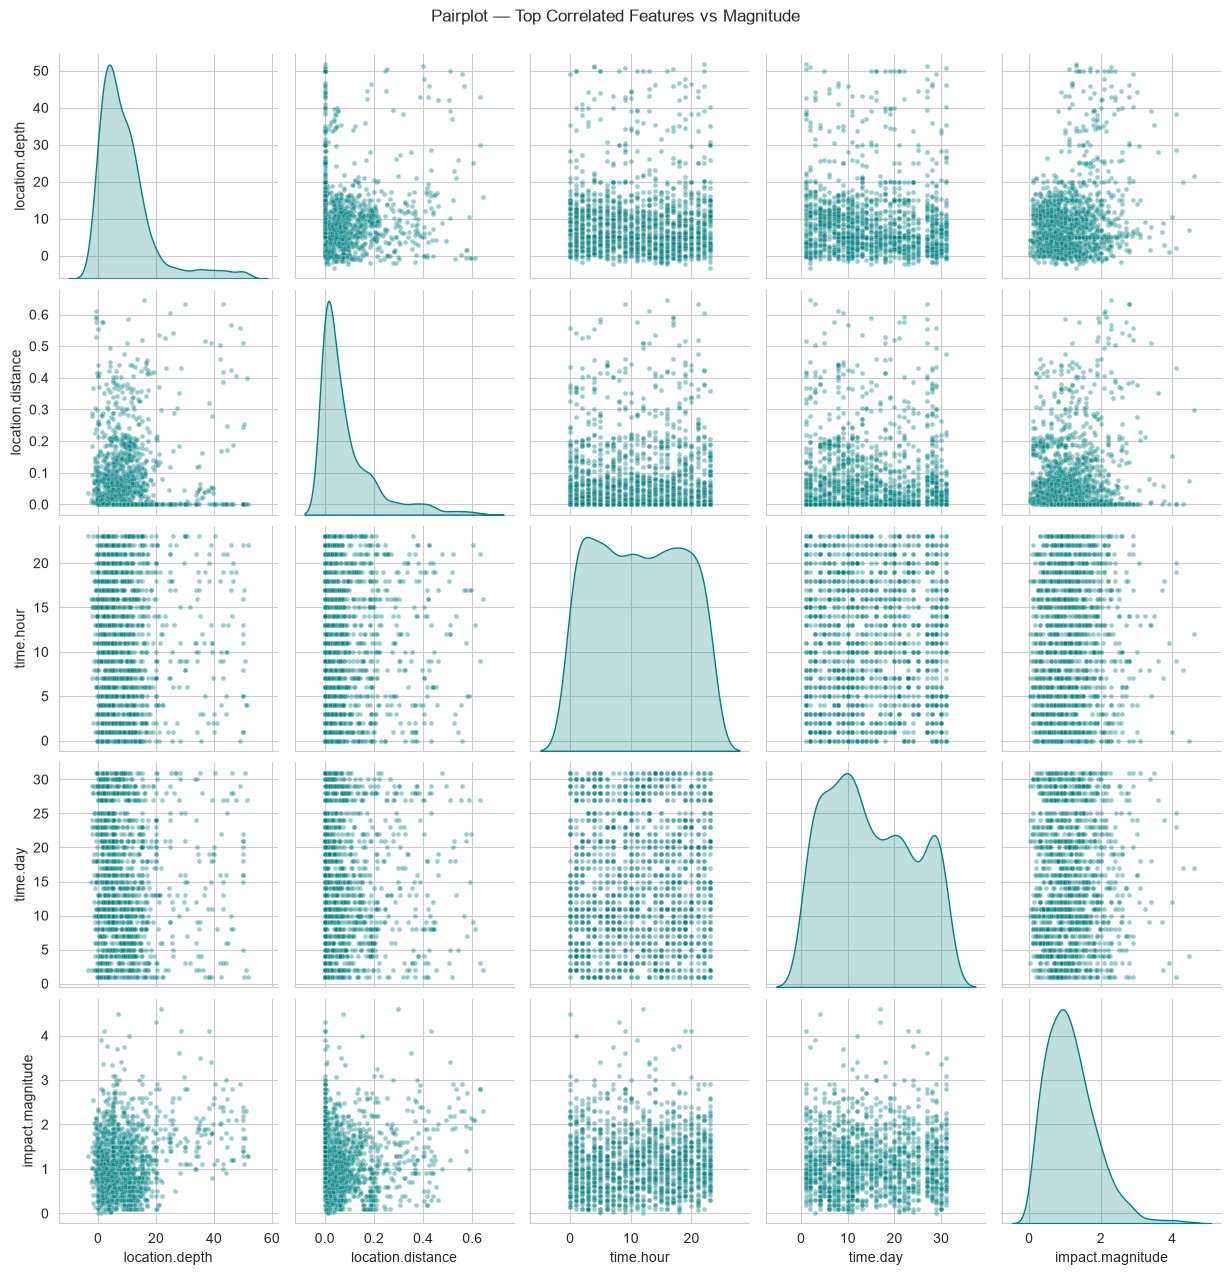

In [17]:
# ============================================================
# 16. PAIRPLOT (Multivariate view)
# ============================================================
# Sample if too large for performance
sample_n = min(1500, len(ds))
pair_ds = ds.sample(sample_n, random_state=RANDOM_STATE)

# Pick top features most correlated with target (max 5 for clarity)
top_feats = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
pair_cols = top_feats + [MAG_COL]

g = sns.pairplot(pair_ds[pair_cols], diag_kind="kde",
                 plot_kws={"alpha": 0.4, "s": 12, "color": "teal"},
                 diag_kws={"color": "teal"})
g.fig.suptitle(f"Pairplot — Top Correlated Features vs Magnitude",
               y=1.02, fontsize=12)
plt.show()

In [18]:
# ============================================================
# 17. FEATURES / TARGET
# ============================================================
X = ds.drop(columns=[MAG_COL])
y = ds[MAG_COL].astype(float)

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Cap categorical cardinality
TOP_CAT = 10
for c in cat_features:
    X[c] = X[c].fillna("missing").astype(str)
    top = X[c].value_counts().nlargest(TOP_CAT).index
    X[c] = X[c].where(X[c].isin(top), other="_other_")

print("Numeric features :", num_features)
print("Categorical feats:", cat_features)
print("Target: y in range", y.min(), "→", y.max())

Numeric features : ['location.depth', 'location.distance', 'location.latitude', 'location.longitude', 'time.day', 'time.hour', 'time.minute', 'time.month', 'time.second', 'time.year']
Categorical feats: ['location.name']
Target: y in range 0.01 → 5.09


In [19]:
# ============================================================
# 18. PREPROCESSING PIPELINE
# ============================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

print("✅ Preprocessor ready")

✅ Preprocessor ready


In [20]:
# ============================================================
# 19. REGRESSION MODELS
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)
print("Train:", X_train_p.shape, "| Test:", X_test_p.shape)

regressors = {
    "DummyMean":        DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(random_state=RANDOM_STATE),
    "Lasso":            Lasso(random_state=RANDOM_STATE, max_iter=5000),
    "SVR":              SVR(),
    "KNeighbors":       KNeighborsRegressor(),
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees":       ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "MLPRegressor":     MLPRegressor(max_iter=500, random_state=RANDOM_STATE)
}

reg_results, reg_preds = [], {}
print("\n--- Regression ---")
for name, model in regressors.items():
    try:
        model.fit(X_train_p, y_train)
        preds = model.predict(X_test_p)
        reg_results.append({
            "model": name,
            "mse":  mean_squared_error(y_test, preds),
            "rmse": np.sqrt(mean_squared_error(y_test, preds)),
            "mae":  mean_absolute_error(y_test, preds),
            "r2":   r2_score(y_test, preds)
        })
        reg_preds[name] = preds
        print(f"{name:20s} R²={reg_results[-1]['r2']:.4f}  RMSE={reg_results[-1]['rmse']:.4f}")
    except Exception as e:
        print(f"{name} failed: {e}")

reg_ds = pd.DataFrame(reg_results).sort_values("r2", ascending=False).reset_index(drop=True)
print("\nRegression Leaderboard:")
print(reg_ds.to_string(index=False))

Train: (5513, 21) | Test: (1379, 21)

--- Regression ---
DummyMean            R²=-0.0000  RMSE=0.6993
LinearRegression     R²=0.3492  RMSE=0.5641
Ridge                R²=0.3492  RMSE=0.5641
Lasso                R²=-0.0000  RMSE=0.6993
SVR                  R²=0.3638  RMSE=0.5577
KNeighbors           R²=0.2383  RMSE=0.6103
RandomForest         R²=0.5236  RMSE=0.4827
ExtraTrees           R²=0.5164  RMSE=0.4863
GradientBoosting     R²=0.4528  RMSE=0.5173
MLPRegressor         R²=0.3452  RMSE=0.5658

Regression Leaderboard:
           model      mse     rmse      mae        r2
    RandomForest 0.232963 0.482663 0.358037  0.523568
      ExtraTrees 0.236473 0.486285 0.363205  0.516390
GradientBoosting 0.267562 0.517264 0.389472  0.452809
             SVR 0.311074 0.557740 0.411975  0.363823
           Ridge 0.318223 0.564112 0.430205  0.349204
LinearRegression 0.318246 0.564133 0.430208  0.349156
    MLPRegressor 0.320180 0.565844 0.428174  0.345201
      KNeighbors 0.372466 0.610300 0.458515 

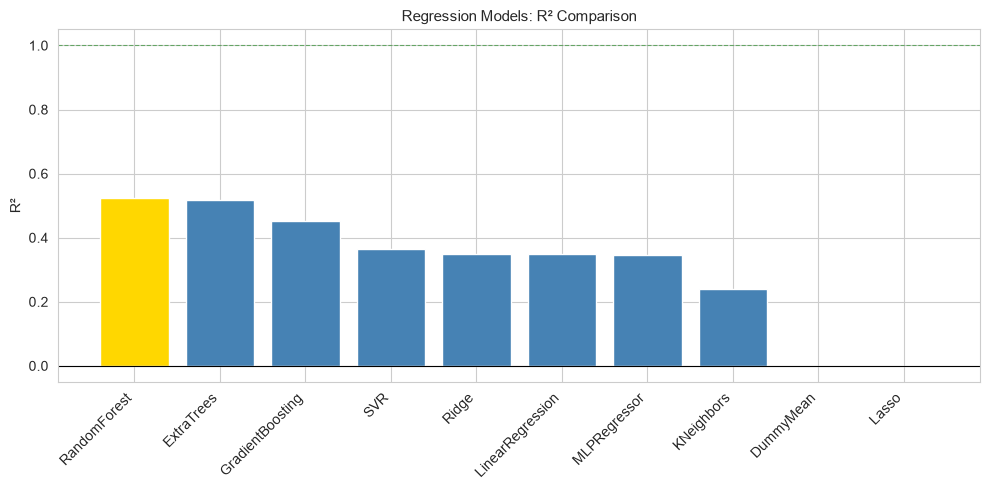

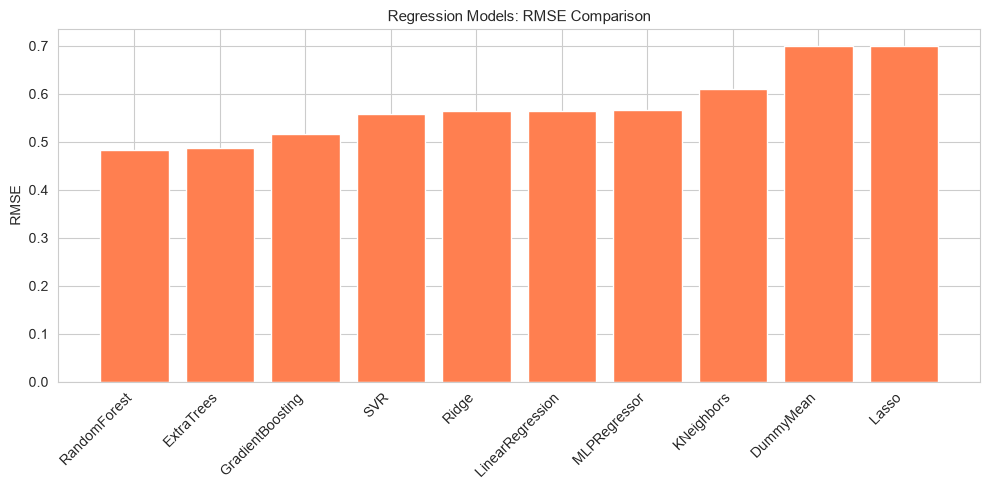

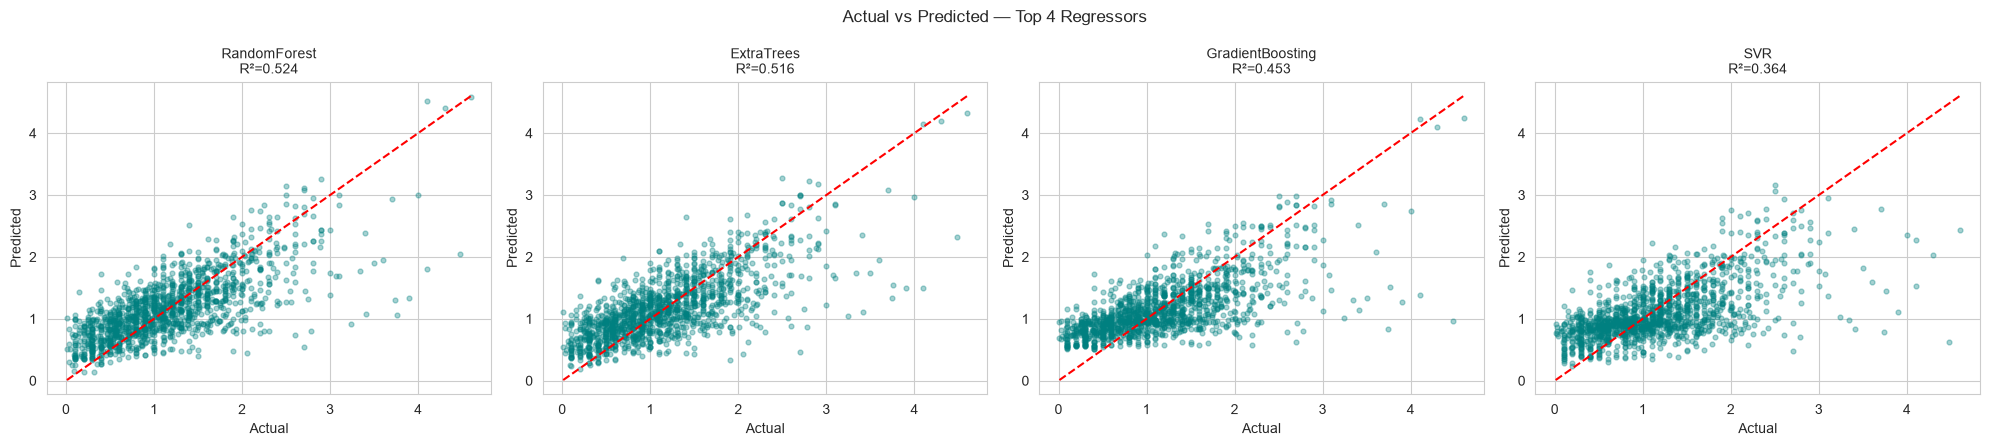

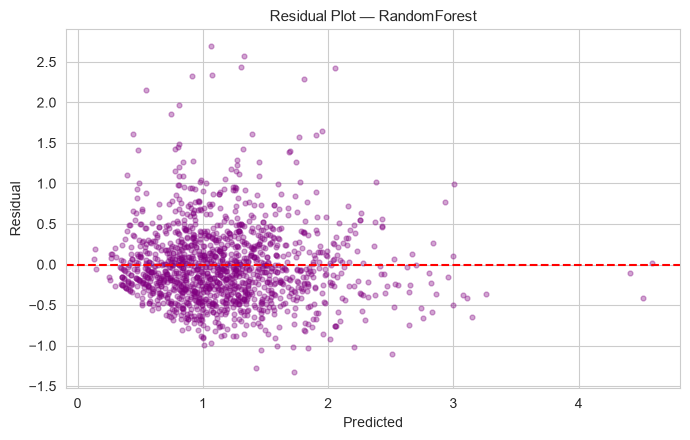

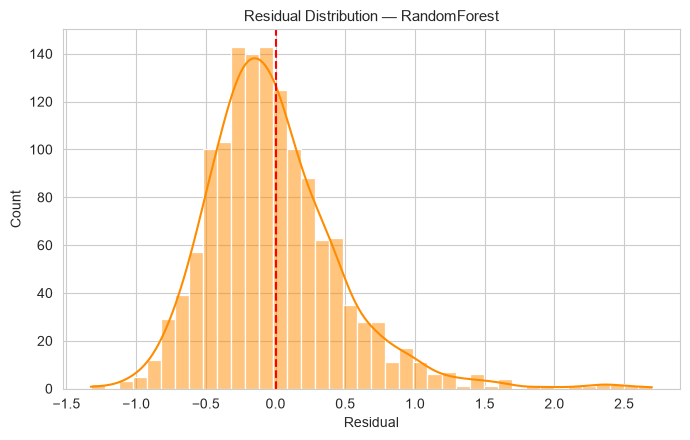

In [21]:
# ============================================================
# 20. REGRESSION VISUALISATIONS
# ============================================================
# R² bar chart
plt.figure(figsize=(10, 5))
colors = ["gold" if m == reg_ds.iloc[0]["model"] else "steelblue" for m in reg_ds["model"]]
plt.bar(reg_ds["model"], reg_ds["r2"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(1, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
plt.title("Regression Models: R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# RMSE bar chart
plt.figure(figsize=(10, 5))
plt.bar(reg_ds["model"], reg_ds["rmse"], color="coral")
plt.title("Regression Models: RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Actual vs Predicted — Top 4
top4 = reg_ds["model"].head(4).tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, top4):
    p = reg_preds[name]
    ax.scatter(y_test, p, alpha=0.35, s=12, color="teal")
    mn, mx = min(y_test.min(), p.min()), max(y_test.max(), p.max())
    ax.plot([mn, mx], [mn, mx], "r--")
    r2v = reg_ds.loc[reg_ds.model == name, "r2"].values[0]
    ax.set_title(f"{name}\nR²={r2v:.3f}", fontsize=10)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
plt.suptitle("Actual vs Predicted — Top 4 Regressors")
plt.tight_layout()
plt.show()

# Residual plot
best_reg = reg_ds.iloc[0]["model"]
residuals = y_test - reg_preds[best_reg]
plt.figure(figsize=(7, 4.5))
plt.scatter(reg_preds[best_reg], residuals, alpha=0.35, s=12, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted"); plt.ylabel("Residual")
plt.title(f"Residual Plot — {best_reg}")
plt.tight_layout()
plt.show()

# Error distribution
plt.figure(figsize=(7, 4.5))
sns.histplot(residuals, bins=40, kde=True, color="darkorange")
plt.axvline(0, color="red", linestyle="--")
plt.title(f"Residual Distribution — {best_reg}")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 21. CLASSIFICATION (QUANTILE BINS — all classes populated)
# ============================================================
q1, q2 = y.quantile(0.33), y.quantile(0.66)
print(f"Class boundaries: Minor < {q1:.2f} ≤ Moderate < {q2:.2f} ≤ Strong")

bins   = [-np.inf, q1, q2, np.inf]
y_class = pd.cut(y, bins=bins, labels=[0, 1, 2]).astype(int)
print("\nClass distribution:")
print(y_class.value_counts().sort_index()
      .rename({0: "Minor", 1: "Moderate", 2: "Strong"}))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.20, random_state=RANDOM_STATE, stratify=y_class
)
Xc_train_p = preprocessor.transform(Xc_train)
Xc_test_p  = preprocessor.transform(Xc_test)

classifiers = {
    "DummyMostFreq":      DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVC":                SVC(probability=True, random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees":         ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLPClassifier":      MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
}

class_results, class_preds = [], {}
print("\n--- Classification ---")
for name, clf in classifiers.items():
    try:
        clf.fit(Xc_train_p, yc_train)
        preds = clf.predict(Xc_test_p)
        class_results.append({
            "model":     name,
            "accuracy":  accuracy_score(yc_test, preds),
            "f1_macro":  f1_score(yc_test, preds, average="macro", zero_division=0)
        })
        class_preds[name] = preds
        print(f"{name:20s} Acc={class_results[-1]['accuracy']:.4f}  F1={class_results[-1]['f1_macro']:.4f}")
    except Exception as e:
        print(f"{name} failed: {e}")

class_ds = pd.DataFrame(class_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\nClassification Leaderboard:")
print(class_ds.to_string(index=False))

Class boundaries: Minor < 0.80 ≤ Moderate < 1.35 ≤ Strong

Class distribution:
impact.magnitude
Minor       2408
Moderate    2147
Strong      2337
Name: count, dtype: int64

--- Classification ---
DummyMostFreq        Acc=0.3495  F1=0.1727
LogisticRegression   Acc=0.5192  F1=0.5014
SVC                  Acc=0.5243  F1=0.5036
KNN                  Acc=0.4851  F1=0.4757
RandomForest         Acc=0.6113  F1=0.6028
ExtraTrees           Acc=0.5990  F1=0.5921
GradientBoosting     Acc=0.5859  F1=0.5825
MLPClassifier        Acc=0.5388  F1=0.5249

Classification Leaderboard:
             model  accuracy  f1_macro
      RandomForest  0.611313  0.602795
        ExtraTrees  0.598985  0.592057
  GradientBoosting  0.585932  0.582509
     MLPClassifier  0.538796  0.524891
               SVC  0.524293  0.503638
LogisticRegression  0.519217  0.501433
               KNN  0.485134  0.475698
     DummyMostFreq  0.349529  0.172667


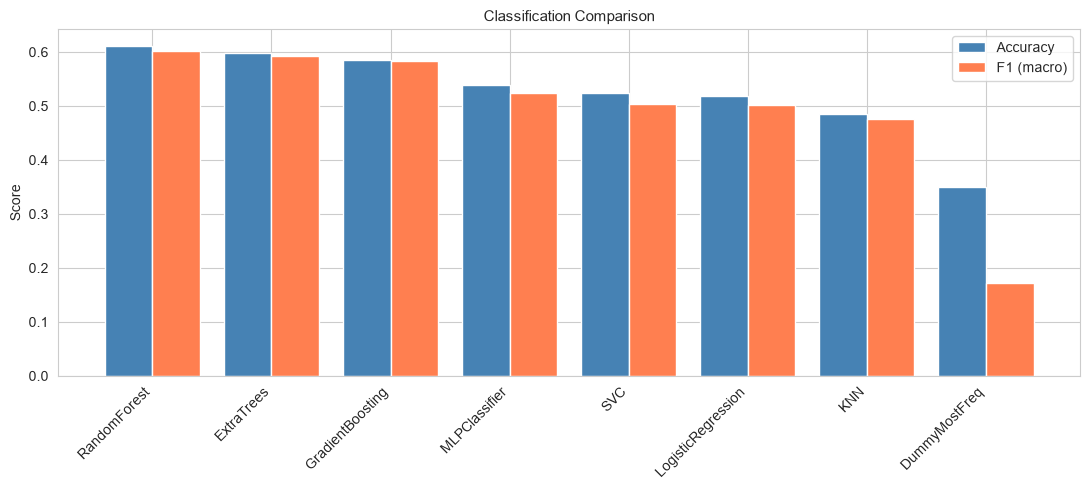

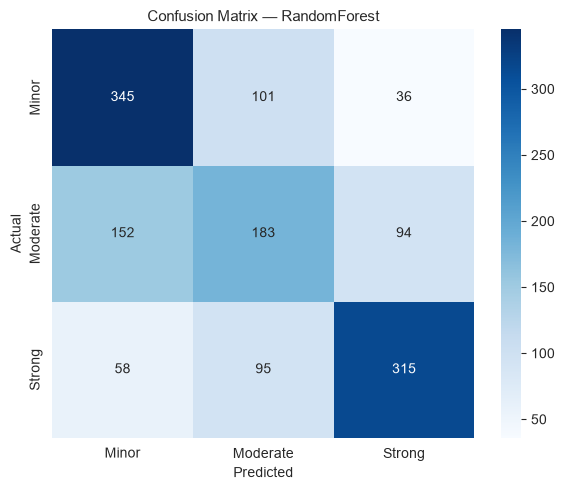


Best classifier: RandomForest
              precision    recall  f1-score   support

       Minor       0.62      0.72      0.67       482
    Moderate       0.48      0.43      0.45       429
      Strong       0.71      0.67      0.69       468

    accuracy                           0.61      1379
   macro avg       0.60      0.61      0.60      1379
weighted avg       0.61      0.61      0.61      1379



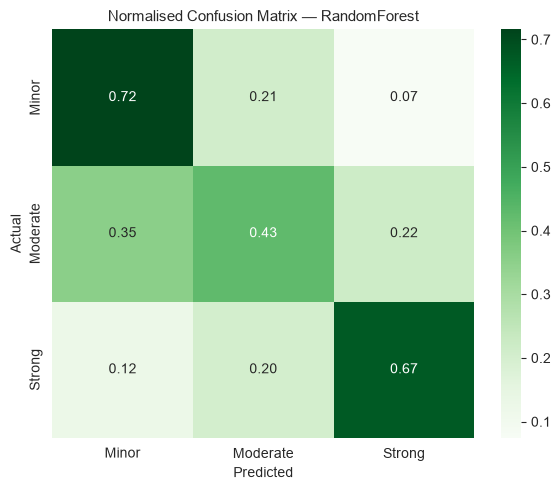

In [23]:
# ============================================================
# 22. CLASSIFICATION VISUALISATIONS
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(class_ds))
ax.bar(x - 0.2, class_ds["accuracy"], width=0.4, label="Accuracy", color="steelblue")
ax.bar(x + 0.2, class_ds["f1_macro"], width=0.4, label="F1 (macro)", color="coral")
ax.set_xticks(x); ax.set_xticklabels(class_ds["model"], rotation=45, ha="right")
ax.set_ylabel("Score"); ax.set_title("Classification Comparison")
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrix for best classifier
best_clf = class_ds.iloc[0]["model"]
cm = confusion_matrix(yc_test, class_preds[best_clf])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Minor", "Moderate", "Strong"],
            yticklabels=["Minor", "Moderate", "Strong"])
plt.title(f"Confusion Matrix — {best_clf}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nBest classifier: {best_clf}")
print(classification_report(yc_test, class_preds[best_clf],
                            target_names=["Minor", "Moderate", "Strong"],
                            zero_division=0))

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=["Minor", "Moderate", "Strong"],
            yticklabels=["Minor", "Moderate", "Strong"])
plt.title(f"Normalised Confusion Matrix — {best_clf}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

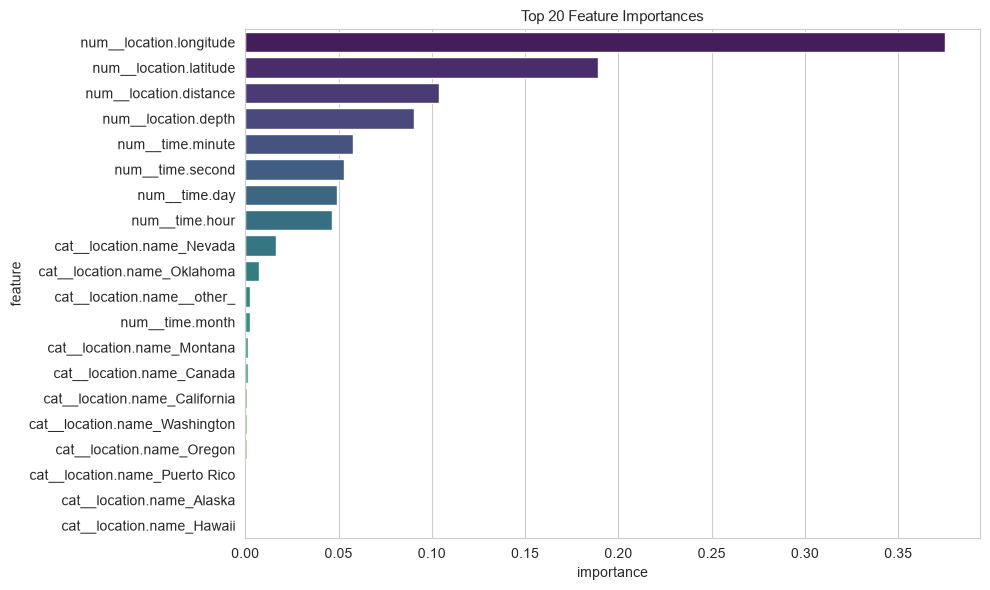


Top 10 features:
                    feature  importance
    num__location.longitude    0.375053
     num__location.latitude    0.188809
     num__location.distance    0.103894
        num__location.depth    0.090546
           num__time.minute    0.057917
           num__time.second    0.053129
              num__time.day    0.049148
             num__time.hour    0.046667
  cat__location.name_Nevada    0.016510
cat__location.name_Oklahoma    0.007348


In [24]:
# ============================================================
# 23. FEATURE IMPORTANCE (Random Forest)
# ============================================================
tree = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
tree.fit(X_train_p, y_train)

try:
    feat_names = preprocessor.get_feature_names_out()
except Exception:
    feat_names = [f"f{i}" for i in range(len(tree.feature_importances_))]

imp = pd.DataFrame({
    "feature": feat_names,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp, x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(imp.head(10).to_string(index=False))

In [25]:
# ============================================================
# 24. FINAL SUMMARY
# ============================================================
print("=" * 60)
print("                  FINAL SUMMARY")
print("=" * 60)
print(f"Best Regressor   : {reg_ds.iloc[0]['model']:20s} R²={reg_ds.iloc[0]['r2']:.4f}")
print(f"Best Classifier  : {class_ds.iloc[0]['model']:20s} F1={class_ds.iloc[0]['f1_macro']:.4f}")
print(f"Dataset size     : {len(ds)} rows × {len(ds.columns)} columns")

print("\n⚠️  SANITY CHECK:")
best_r2 = reg_ds.iloc[0]["r2"]
if best_r2 > 0.95:
    print(f"   R² = {best_r2:.3f} — VERY HIGH. Suspect data leakage!")
    print("   Verify: impact.significance, impact.gap, id, time.epoch are dropped.")
else:
    print(f"   R² = {best_r2:.3f} — Realistic. Model is not leaking.")
print("=" * 60)

                  FINAL SUMMARY
Best Regressor   : RandomForest         R²=0.5236
Best Classifier  : RandomForest         F1=0.6028
Dataset size     : 6892 rows × 12 columns

⚠️  SANITY CHECK:
   R² = 0.524 — Realistic. Model is not leaking.
